# EDA — Province Monthly Rainfall Dataset

Notebook này thực hiện EDA đầy đủ cho file `province_month_rainfall.csv`.

**Mục tiêu chính**
- Kiểm tra cấu trúc dữ liệu, kiểu dữ liệu, missing values, duplicated rows.
- Phân tích phân bố lượng mưa theo tỉnh, tháng, năm.
- Phân tích seasonality, anomaly, z-score và outliers.
- Tạo các bảng summary và biểu đồ phục vụ báo cáo / dashboard / modeling sau này.

In [4]:
# =========================
# 1. Import libraries
# =========================

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

In [5]:
# =========================
# 2. Data path setup
# =========================


CANDIDATE_PATHS = [
    Path("/mnt/disk1/backup_user/minh.ntn/Data_Viz_Project2/data/province_month_rainfall.csv"),
    Path("province_month_rainfall.csv"),
    Path("data/province_month_rainfall.csv"),
    Path("data/raw/province_month_rainfall.csv"),
    Path("data/processed/province_month_rainfall.csv"),
]

DATA_PATH = None
for p in CANDIDATE_PATHS:
    if p.exists():
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "Không tìm thấy province_month_rainfall.csv. "
        "Hãy đặt file cùng thư mục notebook hoặc sửa DATA_PATH thủ công."
    )

print(f"Using data path: {DATA_PATH}")

Using data path: province_month_rainfall.csv


In [6]:
# =========================
# 3. Load dataset
# =========================

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())
display(df.tail())

Shape: (780, 8)


,province_name,year,month,date,rainfall_mm,monthly_mean,rainfall_anomaly,rainfall_zscore
0,Soc Trang,2020,1,2020-01-01,0.717,7.688,-6.971,-0.817
1,Tra Vinh,2020,1,2020-01-01,0.775,5.741,-4.966,-0.770
2,Vinh Long,2020,1,2020-01-01,1.786,6.580,-4.794,-0.605
3,Bac Lieu,2020,1,2020-01-01,4.998,12.795,-7.797,-0.649
4,Ca Mau,2020,1,2020-01-01,7.399,16.231,-8.832,-0.700


,province_name,year,month,date,rainfall_mm,monthly_mean,rainfall_anomaly,rainfall_zscore
775,Ben Tre,2024,12,2024-12-01,89.395,53.101,36.294,1.333
776,Dong Thap,2024,12,2024-12-01,82.432,49.184,33.247,1.113
777,Kien Giang,2024,12,2024-12-01,87.557,52.991,34.566,1.392
778,Long An,2024,12,2024-12-01,87.444,54.576,32.868,1.040
779,Tien Giang,2024,12,2024-12-01,84.150,49.452,34.697,1.284


In [7]:
# =========================
# 4. Basic information
# =========================

print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nBasic info:")
df.info()

Columns:
['province_name', 'year', 'month', 'date', 'rainfall_mm', 'monthly_mean', 'rainfall_anomaly', 'rainfall_zscore']

Data types:


province_name        object
year                  int64
month                 int64
date                 object
rainfall_mm         float64
monthly_mean        float64
rainfall_anomaly    float64
rainfall_zscore     float64
dtype: object


Basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 780 entries, 0 to 779
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   province_name     780 non-null    object 
 1   year              780 non-null    int64  
 2   month             780 non-null    int64  
 3   date              780 non-null    object 
 4   rainfall_mm       780 non-null    float64
 5   monthly_mean      780 non-null    float64
 6   rainfall_anomaly  780 non-null    float64
 7   rainfall_zscore   780 non-null    float64
dtypes: float64(4), int64(2), object(2)
memory usage: 48.9+ KB


In [8]:
# =========================
# 5. Standardize date columns and add useful features
# =========================

df = df.copy()

# Convert date to datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Ensure year/month are numeric
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
df["month"] = pd.to_numeric(df["month"], errors="coerce").astype("Int64")

# Add helper columns
df["year_month"] = df["date"].dt.to_period("M").astype(str)
df["quarter"] = df["date"].dt.quarter
df["month_name"] = df["date"].dt.month_name()

def vietnam_rainfall_season(month):
    # General Vietnam rainfall season grouping.
    # Adjust if your study region uses another definition.
    if month in [5, 6, 7, 8, 9, 10]:
        return "Rainy season"
    return "Dry season"

df["season"] = df["month"].apply(lambda x: vietnam_rainfall_season(int(x)) if pd.notna(x) else np.nan)

print("After preprocessing:")
display(df.head())
display(df.dtypes)

After preprocessing:


,province_name,year,month,date,rainfall_mm,monthly_mean,rainfall_anomaly,rainfall_zscore,year_month,quarter,month_name,season
0,Soc Trang,2020,1,2020-01-01,0.717,7.688,-6.971,-0.817,2020-01,1,January,Dry season
1,Tra Vinh,2020,1,2020-01-01,0.775,5.741,-4.966,-0.770,2020-01,1,January,Dry season
2,Vinh Long,2020,1,2020-01-01,1.786,6.580,-4.794,-0.605,2020-01,1,January,Dry season
3,Bac Lieu,2020,1,2020-01-01,4.998,12.795,-7.797,-0.649,2020-01,1,January,Dry season
4,Ca Mau,2020,1,2020-01-01,7.399,16.231,-8.832,-0.700,2020-01,1,January,Dry season


province_name               object
year                         Int64
month                        Int64
date                datetime64[ns]
rainfall_mm                float64
monthly_mean               float64
rainfall_anomaly           float64
rainfall_zscore            float64
year_month                  object
quarter                      int32
month_name                  object
season                      object
dtype: object

In [9]:
# =========================
# 6. Data quality checks
# =========================

print("Missing values per column:")
display(df.isna().sum().to_frame("missing_count"))

print("\nMissing values ratio:")
display((df.isna().mean() * 100).to_frame("missing_percent"))

print("\nDuplicated rows:", df.duplicated().sum())

# Check duplicated province-year-month records
dup_key = df.duplicated(subset=["province_name", "year", "month"], keep=False)
print("Duplicated province-year-month records:", dup_key.sum())

if dup_key.sum() > 0:
    display(df.loc[dup_key].sort_values(["province_name", "year", "month"]).head(20))

# Check date parsing issues
bad_date = df["date"].isna().sum()
print("Bad/unparsed date rows:", bad_date)

Missing values per column:


,missing_count
province_name,0
year,0
month,0
date,0
rainfall_mm,0
monthly_mean,0
rainfall_anomaly,0
rainfall_zscore,0
year_month,0
quarter,0



Missing values ratio:


,missing_percent
province_name,0.000
year,0.000
month,0.000
date,0.000
rainfall_mm,0.000
monthly_mean,0.000
rainfall_anomaly,0.000
rainfall_zscore,0.000
year_month,0.000
quarter,0.000



Duplicated rows: 0
Duplicated province-year-month records: 0
Bad/unparsed date rows: 0


In [10]:
# =========================
# 7. Coverage check
# =========================

n_provinces = df["province_name"].nunique()
years = sorted(df["year"].dropna().unique().tolist())
months = sorted(df["month"].dropna().unique().tolist())

print(f"Number of provinces: {n_provinces}")
print(f"Years: {years}")
print(f"Months: {months}")
print(f"Date range: {df['date'].min()} -> {df['date'].max()}")

coverage = (
    df.groupby("province_name")
      .agg(
          n_records=("rainfall_mm", "size"),
          min_date=("date", "min"),
          max_date=("date", "max"),
          n_years=("year", "nunique"),
          n_months=("month", "nunique"),
      )
      .reset_index()
      .sort_values("province_name")
)

display(coverage)

Number of provinces: 13
Years: [2020, 2021, 2022, 2023, 2024]
Months: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Date range: 2020-01-01 00:00:00 -> 2024-12-01 00:00:00


,province_name,n_records,min_date,max_date,n_years,n_months
0,An Giang,60,2020-01-01,2024-12-01,5,12
1,Bac Lieu,60,2020-01-01,2024-12-01,5,12
2,Ben Tre,60,2020-01-01,2024-12-01,5,12
3,Ca Mau,60,2020-01-01,2024-12-01,5,12
4,Can Tho city,60,2020-01-01,2024-12-01,5,12
5,Dong Thap,60,2020-01-01,2024-12-01,5,12
6,Hau Giang,60,2020-01-01,2024-12-01,5,12
7,Kien Giang,60,2020-01-01,2024-12-01,5,12
8,Long An,60,2020-01-01,2024-12-01,5,12
9,Soc Trang,60,2020-01-01,2024-12-01,5,12


In [11]:
# =========================
# 8. Completeness matrix: province x year-month
# =========================

expected_periods = pd.period_range(
    df["date"].min().to_period("M"),
    df["date"].max().to_period("M"),
    freq="M"
).astype(str)

complete_index = pd.MultiIndex.from_product(
    [sorted(df["province_name"].unique()), expected_periods],
    names=["province_name", "year_month"]
)

observed = (
    df.assign(year_month=df["date"].dt.to_period("M").astype(str))
      .set_index(["province_name", "year_month"])
      .index
)

missing_combinations = complete_index.difference(observed)

print("Expected province-month combinations:", len(complete_index))
print("Observed province-month combinations:", len(observed))
print("Missing province-month combinations:", len(missing_combinations))

if len(missing_combinations) > 0:
    missing_df = missing_combinations.to_frame(index=False)
    display(missing_df.head(30))
else:
    print("Dataset appears complete for all province-month combinations.")

Expected province-month combinations: 780
Observed province-month combinations: 780
Missing province-month combinations: 0
Dataset appears complete for all province-month combinations.


In [12]:
# =========================
# 9. Numeric summary statistics
# =========================

numeric_cols = ["rainfall_mm", "monthly_mean", "rainfall_anomaly", "rainfall_zscore"]

display(df[numeric_cols].describe().T)

# Additional robust statistics
robust_summary = df[numeric_cols].agg([
    "mean", "median", "std", "min", "max",
    lambda x: x.quantile(0.05),
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75),
    lambda x: x.quantile(0.95),
]).T

robust_summary.columns = [
    "mean", "median", "std", "min", "max",
    "p05", "p25", "p75", "p95"
]

display(robust_summary)

,count,mean,std,min,25%,50%,75%,max
rainfall_mm,780.000,155.478,127.057,0.000,20.123,160.929,244.859,559.464
monthly_mean,780.000,155.478,118.333,2.593,38.257,163.142,241.796,433.793
rainfall_anomaly,780.000,-0.000,46.269,-176.928,-24.020,-3.366,22.988,196.479
rainfall_zscore,780.000,-0.000,0.895,-1.624,-0.724,-0.192,0.737,1.788


,mean,median,std,min,max,p05,p25,p75,p95
rainfall_mm,155.478,160.929,127.057,0.000,559.464,1.762,20.123,244.859,380.115
monthly_mean,155.478,163.142,118.333,2.593,433.793,5.883,38.257,241.796,355.660
rainfall_anomaly,-0.000,-3.366,46.269,-176.928,196.479,-75.771,-24.020,22.988,83.857
rainfall_zscore,-0.000,-0.192,0.895,-1.624,1.788,-1.250,-0.724,0.737,1.543


In [13]:
# =========================
# 10. Helper plotting functions
# =========================

def add_labels(title, xlabel="", ylabel=""):
    plt.title(title, fontsize=14, pad=12)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()

def plot_bar(series, title, xlabel="", ylabel="", rotation=45):
    ax = series.plot(kind="bar", figsize=(12, 6))
    add_labels(title, xlabel, ylabel)
    plt.xticks(rotation=rotation, ha="right")
    plt.show()

def plot_line(data, x, y, title, xlabel="", ylabel="", marker="o"):
    plt.figure(figsize=(13, 6))
    plt.plot(data[x], data[y], marker=marker)
    add_labels(title, xlabel, ylabel)
    plt.show()

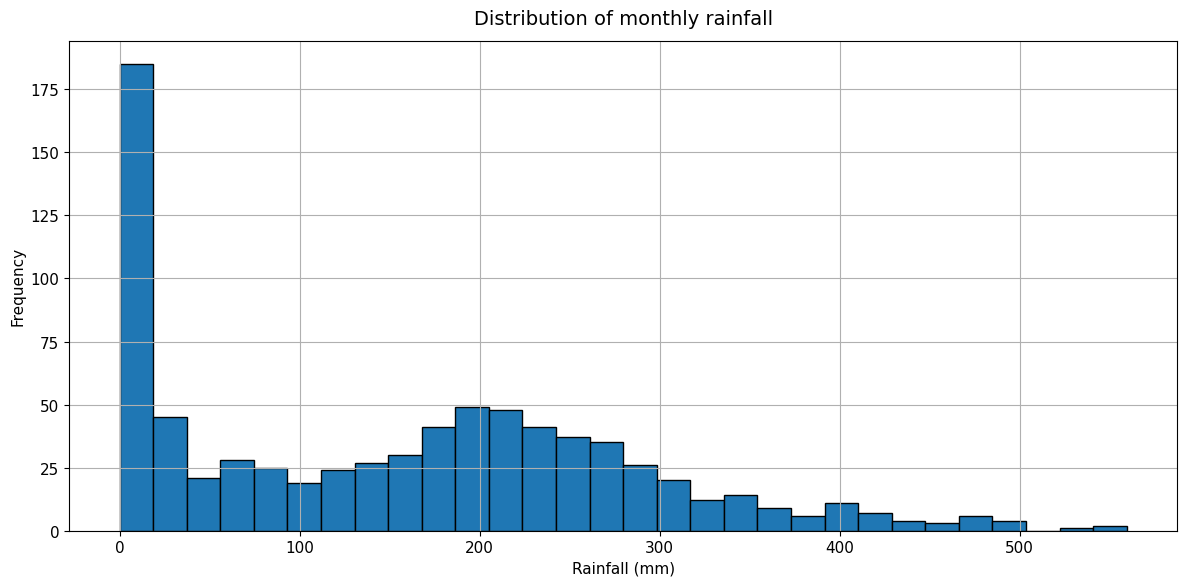

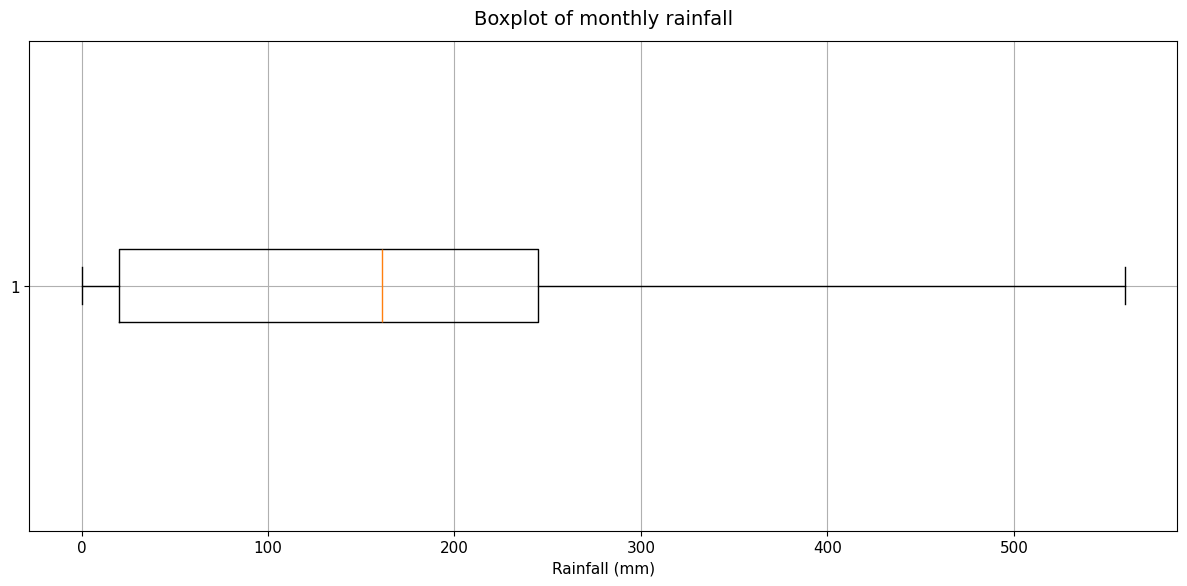

In [14]:
# =========================
# 11. Distribution of rainfall
# =========================

plt.figure(figsize=(12, 6))
plt.hist(df["rainfall_mm"], bins=30, edgecolor="black")
add_labels(
    "Distribution of monthly rainfall",
    "Rainfall (mm)",
    "Frequency"
)
plt.show()

plt.figure(figsize=(12, 6))
plt.boxplot(df["rainfall_mm"].dropna(), vert=False)
add_labels(
    "Boxplot of monthly rainfall",
    "Rainfall (mm)",
    ""
)
plt.show()

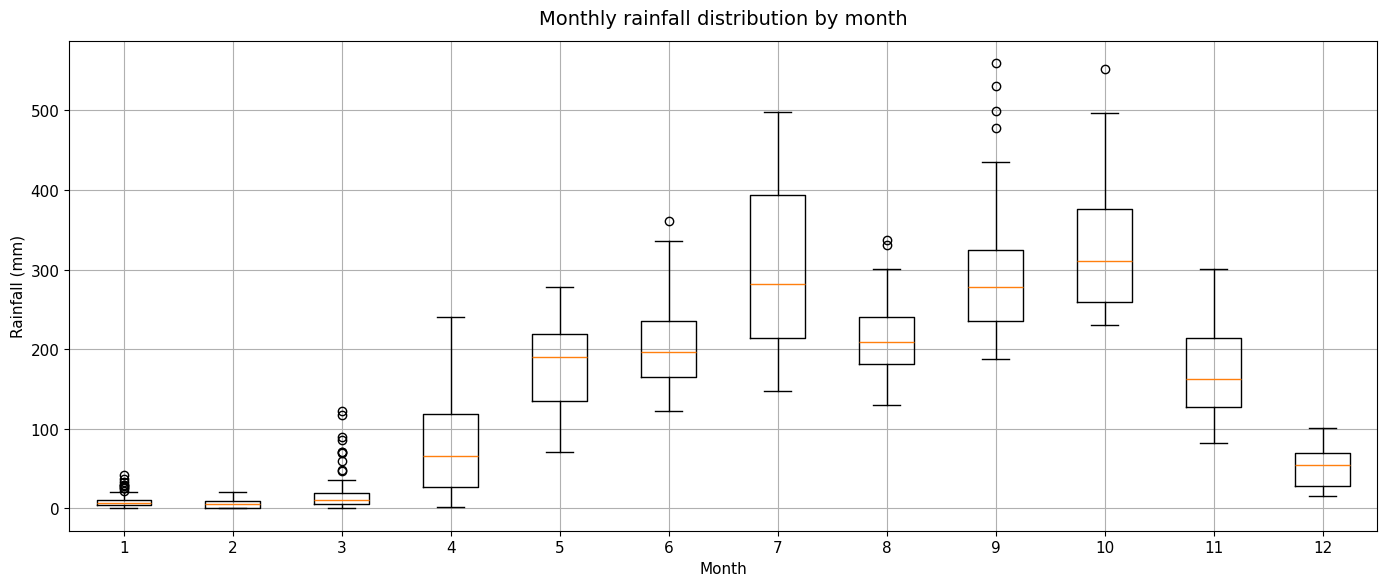

,month,count,mean,median,std,min,max
0,1,65,10.307,7.150,9.655,0.003,42.598
1,2,65,6.073,6.127,5.564,0.000,20.461
2,3,65,20.723,9.999,27.455,0.791,121.863
3,4,65,80.503,66.432,65.355,2.284,240.187
4,5,65,179.631,190.190,54.244,70.307,278.322
5,6,65,208.071,196.172,57.894,122.086,361.039
6,7,65,301.953,282.094,100.491,147.610,498.344
7,8,65,214.813,209.204,46.119,129.877,337.029
8,9,65,295.417,277.474,80.670,187.283,559.464
9,10,65,324.874,311.352,73.232,230.046,552.139


In [15]:
# =========================
# 12. Rainfall distribution by month
# =========================

month_order = list(range(1, 13))
monthly_box_data = [
    df.loc[df["month"] == m, "rainfall_mm"].dropna()
    for m in month_order
]

plt.figure(figsize=(14, 6))
plt.boxplot(monthly_box_data, labels=month_order, showfliers=True)
add_labels(
    "Monthly rainfall distribution by month",
    "Month",
    "Rainfall (mm)"
)
plt.show()

monthly_stats = (
    df.groupby("month")["rainfall_mm"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .reset_index()
)

display(monthly_stats)

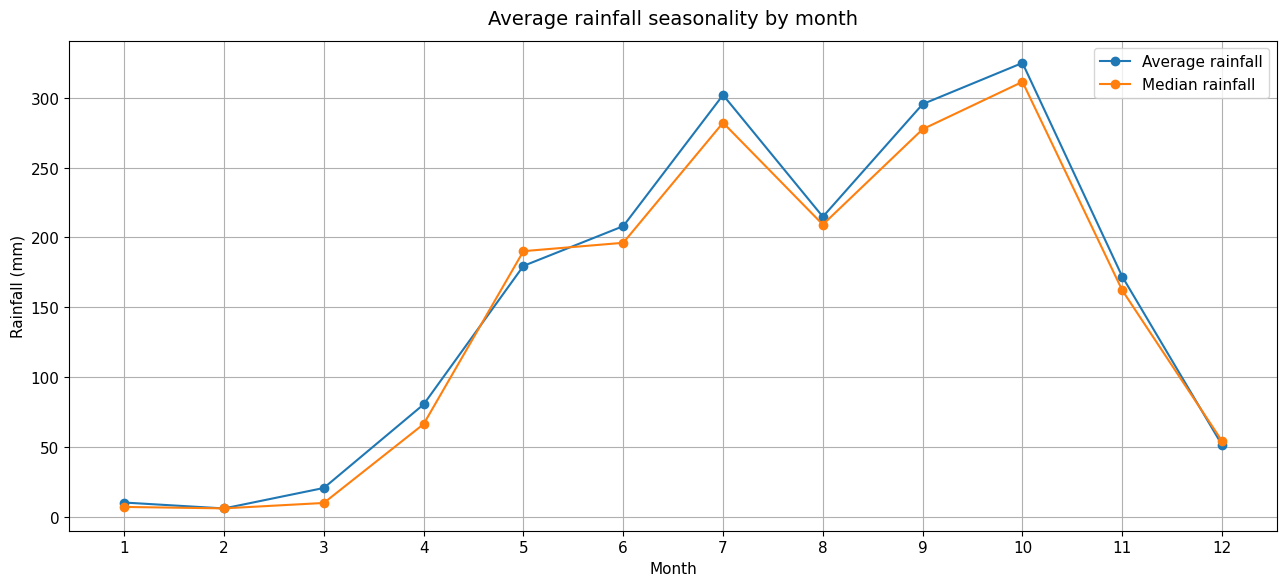

,month,avg_rainfall,median_rainfall,avg_monthly_mean,avg_anomaly
0,1,10.307,7.150,10.307,0.000
1,2,6.073,6.127,6.073,-0.000
2,3,20.723,9.999,20.723,-0.000
3,4,80.503,66.432,80.503,-0.000
4,5,179.631,190.190,179.631,-0.000
5,6,208.071,196.172,208.071,-0.000
6,7,301.953,282.094,301.953,0.000
7,8,214.813,209.204,214.813,-0.000
8,9,295.417,277.474,295.417,0.000
9,10,324.874,311.352,324.874,0.000


In [16]:
# =========================
# 13. Average seasonal pattern
# =========================

monthly_mean = (
    df.groupby("month", as_index=False)
      .agg(
          avg_rainfall=("rainfall_mm", "mean"),
          median_rainfall=("rainfall_mm", "median"),
          avg_monthly_mean=("monthly_mean", "mean"),
          avg_anomaly=("rainfall_anomaly", "mean"),
      )
)

plt.figure(figsize=(13, 6))
plt.plot(monthly_mean["month"], monthly_mean["avg_rainfall"], marker="o", label="Average rainfall")
plt.plot(monthly_mean["month"], monthly_mean["median_rainfall"], marker="o", label="Median rainfall")
plt.xticks(range(1, 13))
plt.legend()
add_labels(
    "Average rainfall seasonality by month",
    "Month",
    "Rainfall (mm)"
)
plt.show()

display(monthly_mean)

,n_records,avg_rainfall,median_rainfall,std_rainfall,total_rainfall,avg_anomaly
season,,,,,,
Rainy season,390,254.126,240.017,89.685,"99,109.317",-0.000
Dry season,390,56.830,20.109,69.081,"22,163.546",-0.000


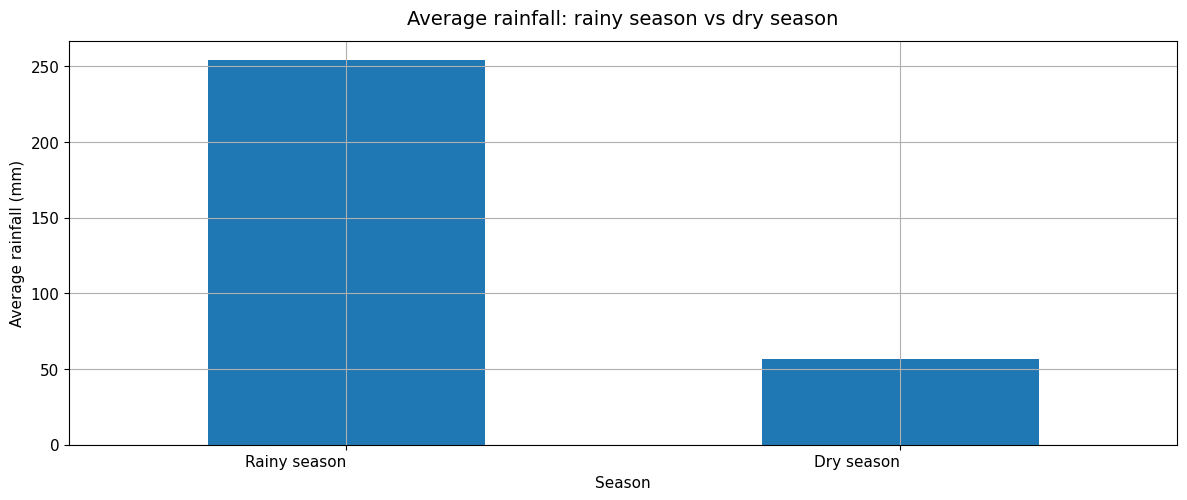

In [17]:
# =========================
# 14. Rainy season vs dry season
# =========================

season_stats = (
    df.groupby("season")
      .agg(
          n_records=("rainfall_mm", "size"),
          avg_rainfall=("rainfall_mm", "mean"),
          median_rainfall=("rainfall_mm", "median"),
          std_rainfall=("rainfall_mm", "std"),
          total_rainfall=("rainfall_mm", "sum"),
          avg_anomaly=("rainfall_anomaly", "mean"),
      )
      .sort_values("avg_rainfall", ascending=False)
)

display(season_stats)

plot_bar(
    season_stats["avg_rainfall"],
    "Average rainfall: rainy season vs dry season",
    "Season",
    "Average rainfall (mm)",
    rotation=0
)

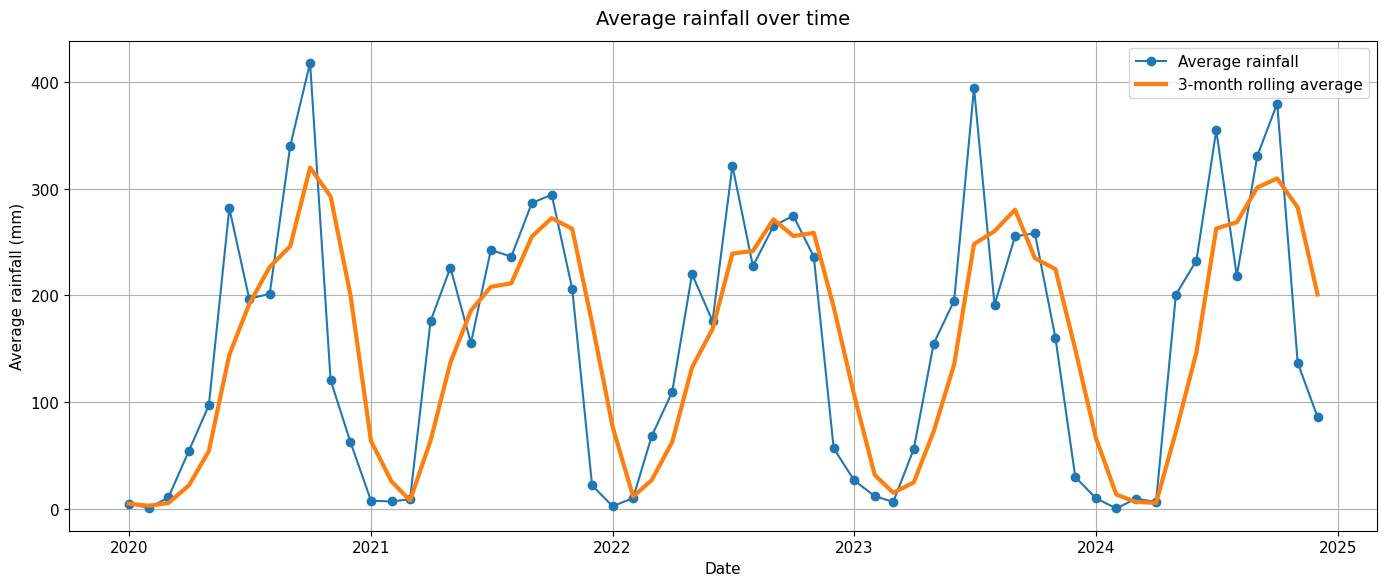

,date,avg_rainfall,total_rainfall,avg_anomaly,avg_zscore
0,2020-01-01,4.790,62.265,-5.517,-0.585
1,2020-02-01,1.010,13.124,-5.064,-0.930
2,2020-03-01,10.656,138.530,-10.067,-0.370
3,2020-04-01,54.486,708.318,-26.017,-0.411
4,2020-05-01,96.946,"1,260.302",-82.685,-1.467


In [18]:
# =========================
# 15. Overall rainfall over time
# =========================

overall_time = (
    df.groupby("date", as_index=False)
      .agg(
          avg_rainfall=("rainfall_mm", "mean"),
          total_rainfall=("rainfall_mm", "sum"),
          avg_anomaly=("rainfall_anomaly", "mean"),
          avg_zscore=("rainfall_zscore", "mean"),
      )
      .sort_values("date")
)

plt.figure(figsize=(14, 6))
plt.plot(overall_time["date"], overall_time["avg_rainfall"], marker="o", label="Average rainfall")
plt.plot(
    overall_time["date"],
    overall_time["avg_rainfall"].rolling(3, min_periods=1).mean(),
    linewidth=3,
    label="3-month rolling average"
)
plt.legend()
add_labels(
    "Average rainfall over time",
    "Date",
    "Average rainfall (mm)"
)
plt.show()

display(overall_time.head())

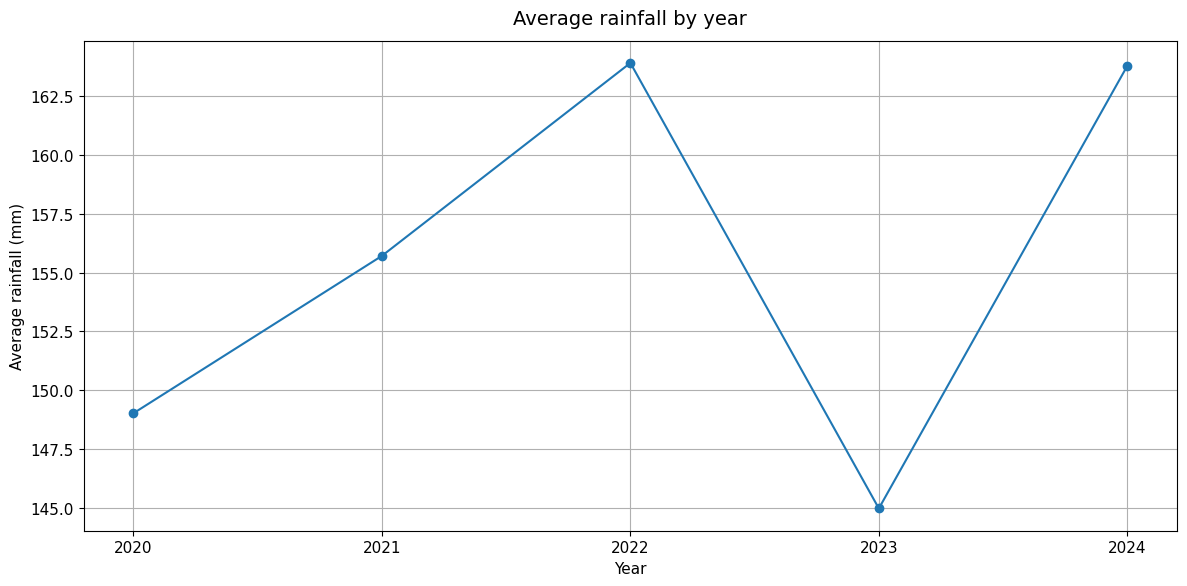

,year,avg_rainfall,total_rainfall,avg_anomaly,avg_zscore
0,2020,149.019,"23,247.004",-6.459,-0.219
1,2021,155.708,"24,290.433",0.230,0.005
2,2022,163.907,"25,569.549",8.429,0.275
3,2023,144.972,"22,615.684",-10.506,-0.144
4,2024,163.783,"25,550.192",8.305,0.084


In [19]:
# =========================
# 16. Yearly rainfall trend
# =========================

yearly_stats = (
    df.groupby("year")
      .agg(
          avg_rainfall=("rainfall_mm", "mean"),
          total_rainfall=("rainfall_mm", "sum"),
          avg_anomaly=("rainfall_anomaly", "mean"),
          avg_zscore=("rainfall_zscore", "mean"),
      )
      .reset_index()
)

plt.figure(figsize=(12, 6))
plt.plot(yearly_stats["year"], yearly_stats["avg_rainfall"], marker="o")
plt.xticks(yearly_stats["year"])
add_labels(
    "Average rainfall by year",
    "Year",
    "Average rainfall (mm)"
)
plt.show()

display(yearly_stats)

,n_records,avg_rainfall,median_rainfall,std_rainfall,min_rainfall,max_rainfall,total_rainfall,avg_anomaly,avg_zscore
province_name,,,,,,,,,
Ca Mau,60,196.443,199.001,159.411,0.024,559.464,"11,786.595",-0.000,-0.000
Kien Giang,60,184.567,187.807,144.508,0.274,498.344,"11,074.006",0.000,0.000
Bac Lieu,60,184.402,191.325,150.349,0.025,498.984,"11,064.103",0.000,-0.000
Hau Giang,60,171.126,185.412,137.076,0.058,497.324,"10,267.562",-0.000,-0.000
Soc Trang,60,167.606,168.269,140.757,0.406,475.929,"10,056.366",0.000,0.000
Long An,60,148.892,160.582,113.361,0.379,354.121,"8,933.525",0.000,0.000
Can Tho city,60,145.736,167.415,112.994,0.000,394.521,"8,744.187",-0.000,-0.000
Tra Vinh,60,145.139,142.676,125.372,0.082,435.932,"8,708.358",-0.000,-0.000
Vinh Long,60,145.067,155.445,118.058,0.000,423.634,"8,704.001",0.000,0.000


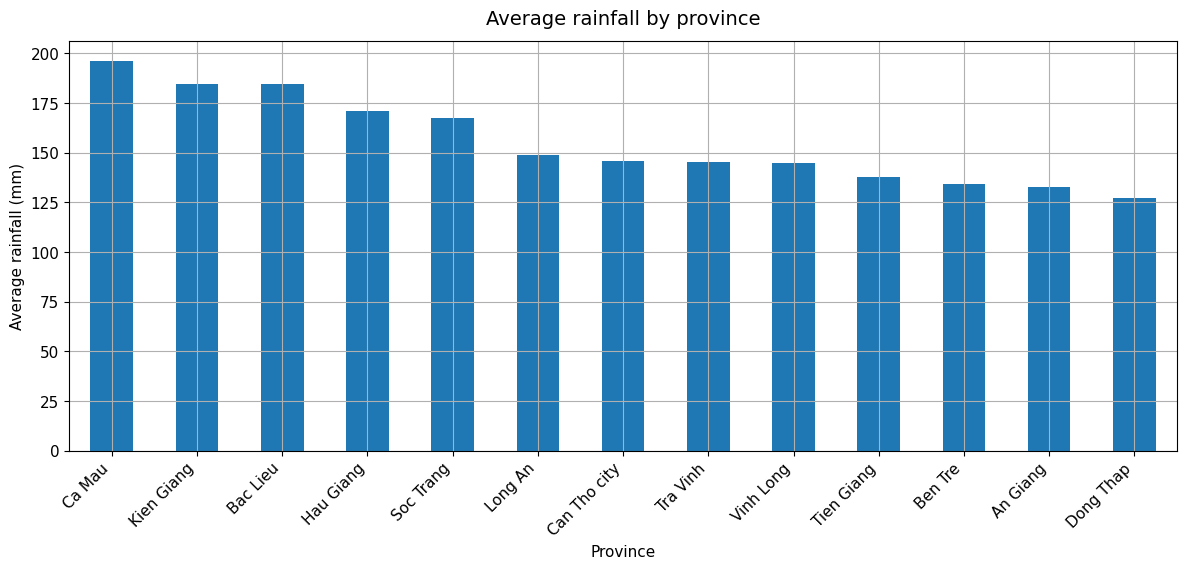

In [20]:
# =========================
# 17. Province-level rainfall ranking
# =========================

province_stats = (
    df.groupby("province_name")
      .agg(
          n_records=("rainfall_mm", "size"),
          avg_rainfall=("rainfall_mm", "mean"),
          median_rainfall=("rainfall_mm", "median"),
          std_rainfall=("rainfall_mm", "std"),
          min_rainfall=("rainfall_mm", "min"),
          max_rainfall=("rainfall_mm", "max"),
          total_rainfall=("rainfall_mm", "sum"),
          avg_anomaly=("rainfall_anomaly", "mean"),
          avg_zscore=("rainfall_zscore", "mean"),
      )
      .sort_values("avg_rainfall", ascending=False)
)

display(province_stats)

plot_bar(
    province_stats["avg_rainfall"],
    "Average rainfall by province",
    "Province",
    "Average rainfall (mm)",
    rotation=45
)

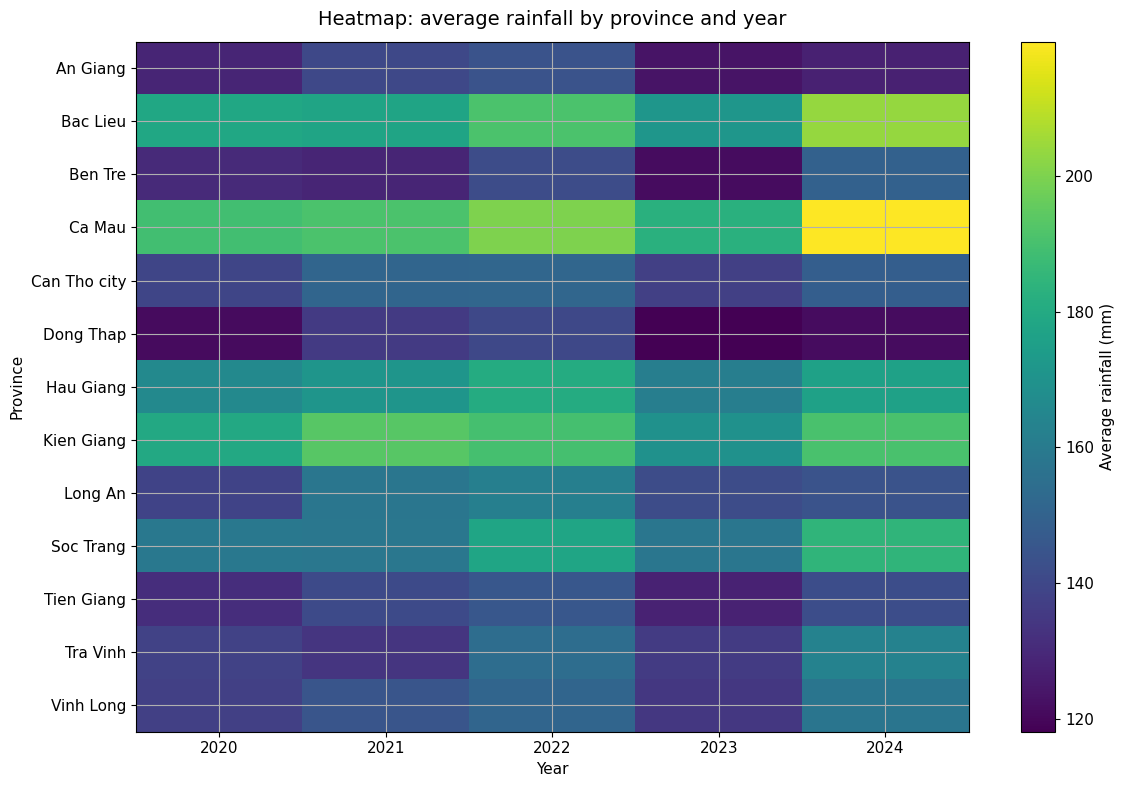

year,2020,2021,2022,2023,2024
province_name,,,,,
An Giang,128.830,140.359,144.320,123.592,127.341
Bac Lieu,178.715,177.322,191.026,171.478,203.468
Ben Tre,130.345,128.663,141.729,121.624,149.818
Ca Mau,188.836,190.813,200.032,182.805,219.731
Can Tho city,139.576,151.335,151.879,137.524,148.368
Dong Thap,121.192,135.556,140.090,118.162,121.496
Hau Giang,166.010,171.004,180.768,161.486,176.361
Kien Giang,179.474,193.495,189.700,169.692,190.472
Long An,138.525,157.911,161.923,141.827,144.274


In [21]:
# =========================
# 18. Province x year heatmap
# =========================

province_year = (
    df.groupby(["province_name", "year"])["rainfall_mm"]
      .mean()
      .unstack("year")
      .sort_index()
)

plt.figure(figsize=(12, 8))
plt.imshow(province_year.values, aspect="auto")
plt.colorbar(label="Average rainfall (mm)")
plt.xticks(range(len(province_year.columns)), province_year.columns)
plt.yticks(range(len(province_year.index)), province_year.index)
add_labels(
    "Heatmap: average rainfall by province and year",
    "Year",
    "Province"
)
plt.show()

display(province_year)

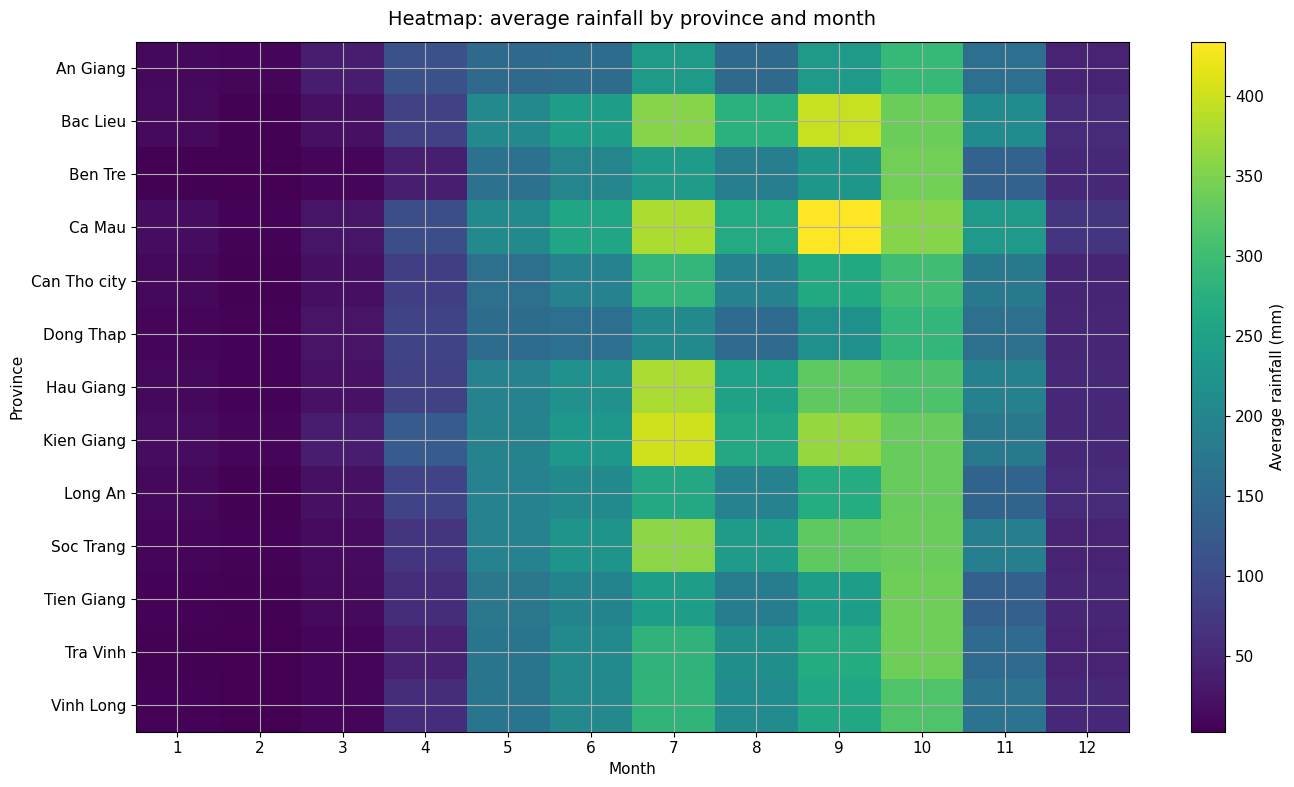

month,1,2,3,4,5,6,7,8,9,10,11,12
province_name,,,,,,,,,,,,
An Giang,12.030,9.530,35.148,109.169,151.616,155.836,238.045,151.441,235.708,290.764,159.772,45.600
Bac Lieu,12.795,5.962,21.581,88.218,205.532,244.977,354.635,278.295,397.926,337.609,209.896,55.394
Ben Tre,5.404,3.883,9.808,38.797,163.693,198.699,241.458,187.569,230.499,341.698,138.618,53.101
Ca Mau,16.231,6.863,27.078,105.881,206.703,255.985,381.516,266.720,433.793,355.660,233.411,67.479
Can Tho city,11.195,5.587,20.562,82.364,162.591,193.574,287.657,194.541,264.446,301.435,176.853,48.032
Dong Thap,10.614,6.367,25.135,90.713,154.813,159.819,207.000,153.869,219.525,288.827,161.722,49.184
Hau Giang,11.449,6.153,22.848,86.991,193.029,219.887,379.314,249.573,327.101,313.941,191.323,51.905
Kien Giang,16.630,10.843,36.637,127.176,196.287,232.145,402.488,262.232,366.374,333.291,177.706,52.991
Long An,11.221,5.883,22.797,89.724,192.978,208.036,262.712,193.918,269.877,333.066,141.916,54.576


In [22]:
# =========================
# 19. Province x month seasonality heatmap
# =========================

province_month = (
    df.groupby(["province_name", "month"])["rainfall_mm"]
      .mean()
      .unstack("month")
      .sort_index()
)

plt.figure(figsize=(14, 8))
plt.imshow(province_month.values, aspect="auto")
plt.colorbar(label="Average rainfall (mm)")
plt.xticks(range(len(province_month.columns)), province_month.columns)
plt.yticks(range(len(province_month.index)), province_month.index)
add_labels(
    "Heatmap: average rainfall by province and month",
    "Month",
    "Province"
)
plt.show()

display(province_month)

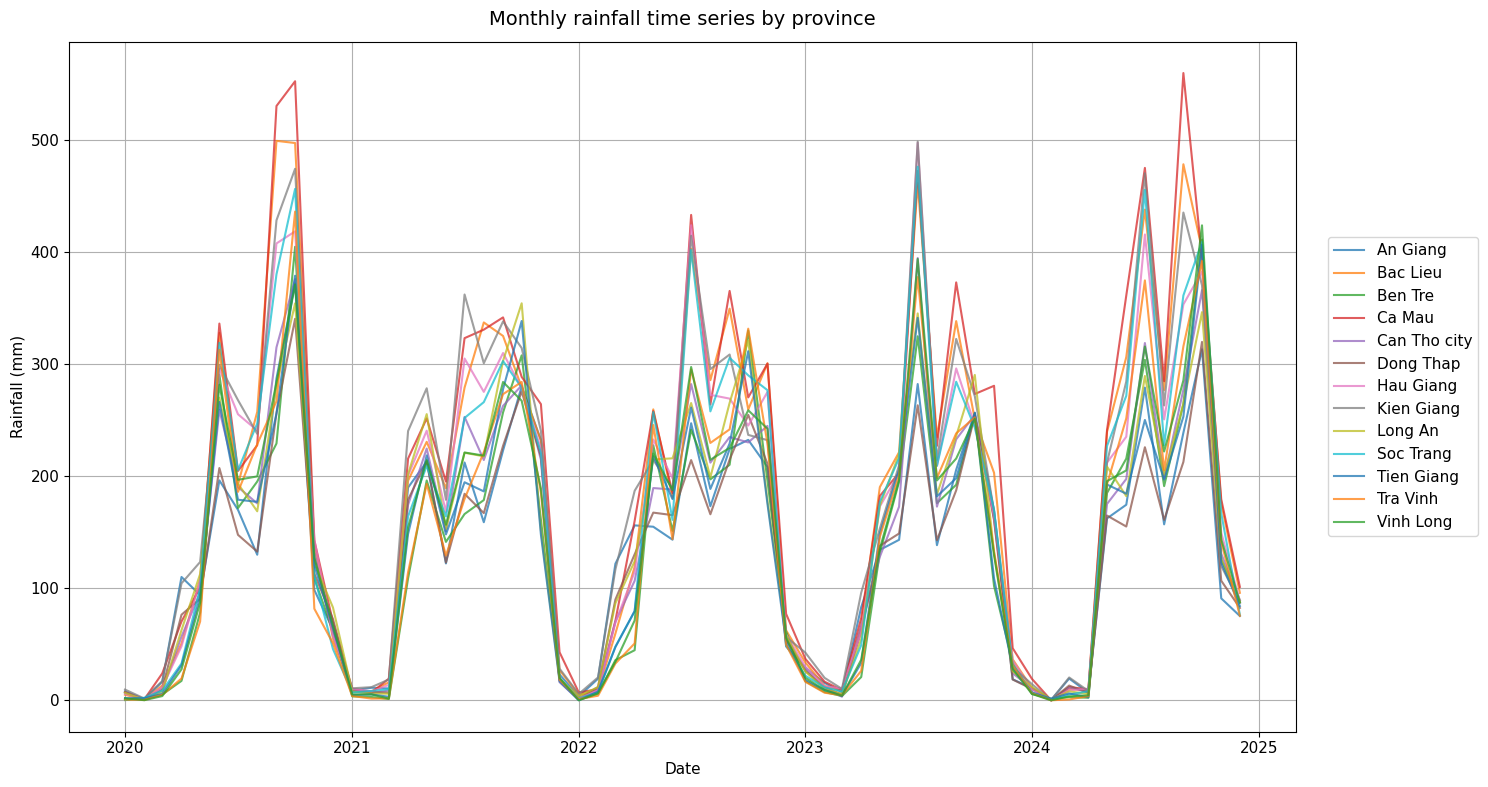

In [23]:
# =========================
# 20. Time series by province
# =========================

province_time = (
    df.groupby(["date", "province_name"], as_index=False)
      .agg(avg_rainfall=("rainfall_mm", "mean"))
      .sort_values(["province_name", "date"])
)

plt.figure(figsize=(15, 8))
for province, g in province_time.groupby("province_name"):
    plt.plot(g["date"], g["avg_rainfall"], alpha=0.75, label=province)

plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
add_labels(
    "Monthly rainfall time series by province",
    "Date",
    "Rainfall (mm)"
)
plt.show()

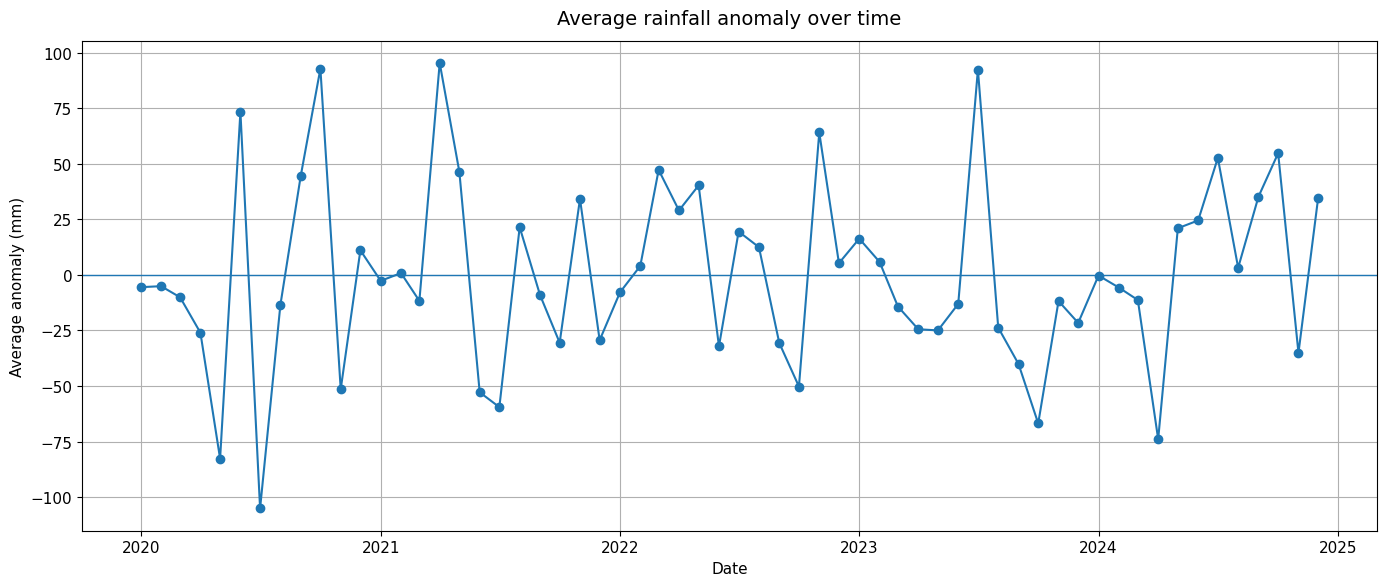

Top 15 positive rainfall anomaly records:


,province_name,year,month,date,rainfall_mm,monthly_mean,rainfall_anomaly,rainfall_zscore,year_month,quarter,month_name,season
121,Ca Mau,2020,10,2020-10-01,552.139,355.660,196.479,1.622,2020-10,4,October,Rainy season
120,Bac Lieu,2020,10,2020-10-01,497.048,337.609,159.439,1.476,2020-10,4,October,Rainy season
127,Kien Giang,2020,10,2020-10-01,474.080,333.291,140.789,1.511,2020-10,4,October,Rainy season
732,Ca Mau,2024,9,2024-09-01,559.464,433.793,125.671,1.226,2024-09,3,September,Rainy season
117,Soc Trang,2020,10,2020-10-01,456.139,335.412,120.727,1.314,2020-10,4,October,Rainy season
552,Hau Giang,2023,7,2023-07-01,497.324,379.314,118.011,1.208,2023-07,3,July,Rainy season
546,Soc Trang,2023,7,2023-07-01,475.929,358.010,117.919,0.964,2023-07,3,July,Rainy season
201,Hau Giang,2021,4,2021-04-01,200.351,86.991,113.360,1.541,2021-04,2,April,Dry season
205,Kien Giang,2021,4,2021-04-01,240.187,127.176,113.011,1.265,2021-04,2,April,Dry season
206,Long An,2021,4,2021-04-01,201.704,89.724,111.980,1.485,2021-04,2,April,Dry season


Top 15 negative rainfall anomaly records:


,province_name,year,month,date,rainfall_mm,monthly_mean,rainfall_anomaly,rainfall_zscore,year_month,quarter,month_name,season
82,Ca Mau,2020,7,2020-07-01,204.589,381.516,-176.928,-1.519,2020-07,3,July,Rainy season
81,Bac Lieu,2020,7,2020-07-01,192.459,354.635,-162.176,-1.414,2020-07,3,July,Rainy season
78,Soc Trang,2020,7,2020-07-01,205.274,358.010,-152.736,-1.248,2020-07,3,July,Rainy season
88,Kien Giang,2020,7,2020-07-01,267.731,402.488,-134.758,-1.468,2020-07,3,July,Rainy season
84,Hau Giang,2020,7,2020-07-01,255.164,379.314,-124.149,-1.271,2020-07,3,July,Rainy season
673,Kien Giang,2024,4,2024-04-01,8.336,127.176,-118.840,-1.330,2024-04,2,April,Dry season
234,Soc Trang,2021,7,2021-07-01,251.883,358.010,-106.127,-0.868,2021-07,3,July,Rainy season
56,Ca Mau,2020,5,2020-05-01,100.708,206.703,-105.996,-1.596,2020-05,2,May,Rainy season
235,Tra Vinh,2021,7,2021-07-01,179.624,282.562,-102.938,-1.062,2021-07,3,July,Rainy season
670,An Giang,2024,4,2024-04-01,6.834,109.169,-102.335,-1.453,2024-04,2,April,Dry season


In [24]:
# =========================
# 21. Anomaly analysis over time
# =========================

plt.figure(figsize=(14, 6))
plt.axhline(0, linewidth=1)
plt.plot(overall_time["date"], overall_time["avg_anomaly"], marker="o")
add_labels(
    "Average rainfall anomaly over time",
    "Date",
    "Average anomaly (mm)"
)
plt.show()

# Top positive / negative anomaly months across all province-month rows
top_positive_anomaly = df.sort_values("rainfall_anomaly", ascending=False).head(15)
top_negative_anomaly = df.sort_values("rainfall_anomaly", ascending=True).head(15)

print("Top 15 positive rainfall anomaly records:")
display(top_positive_anomaly)

print("Top 15 negative rainfall anomaly records:")
display(top_negative_anomaly)

Extreme records using |z| >= 1.5: 57
Extreme records using |z| >= 2.0: 0


,province_name,year,month,date,rainfall_mm,monthly_mean,rainfall_anomaly,rainfall_zscore,year_month,quarter,month_name,season,z_extreme_1_5,z_extreme_2_0
349,Long An,2022,3,2022-03-01,86.564,22.797,63.767,1.788,2022-03,1,March,Dry season,True,False
350,Tien Giang,2022,3,2022-03-01,47.505,13.365,34.140,1.785,2022-03,1,March,Dry season,True,False
344,Hau Giang,2022,3,2022-03-01,69.223,22.848,46.376,1.785,2022-03,1,March,Dry season,True,False
340,Vinh Long,2022,3,2022-03-01,34.327,9.479,24.848,1.784,2022-03,1,March,Dry season,True,False
348,Kien Giang,2022,3,2022-03-01,116.796,36.637,80.159,1.782,2022-03,1,March,Dry season,True,False
347,Dong Thap,2022,3,2022-03-01,89.932,25.135,64.797,1.782,2022-03,1,March,Dry season,True,False
338,Soc Trang,2022,3,2022-03-01,47.981,15.995,31.986,1.781,2022-03,1,March,Dry season,True,False
346,Ben Tre,2022,3,2022-03-01,35.897,9.808,26.089,1.780,2022-03,1,March,Dry season,True,False
345,An Giang,2022,3,2022-03-01,121.863,35.148,86.715,1.780,2022-03,1,March,Dry season,True,False
343,Can Tho city,2022,3,2022-03-01,70.265,20.562,49.703,1.778,2022-03,1,March,Dry season,True,False


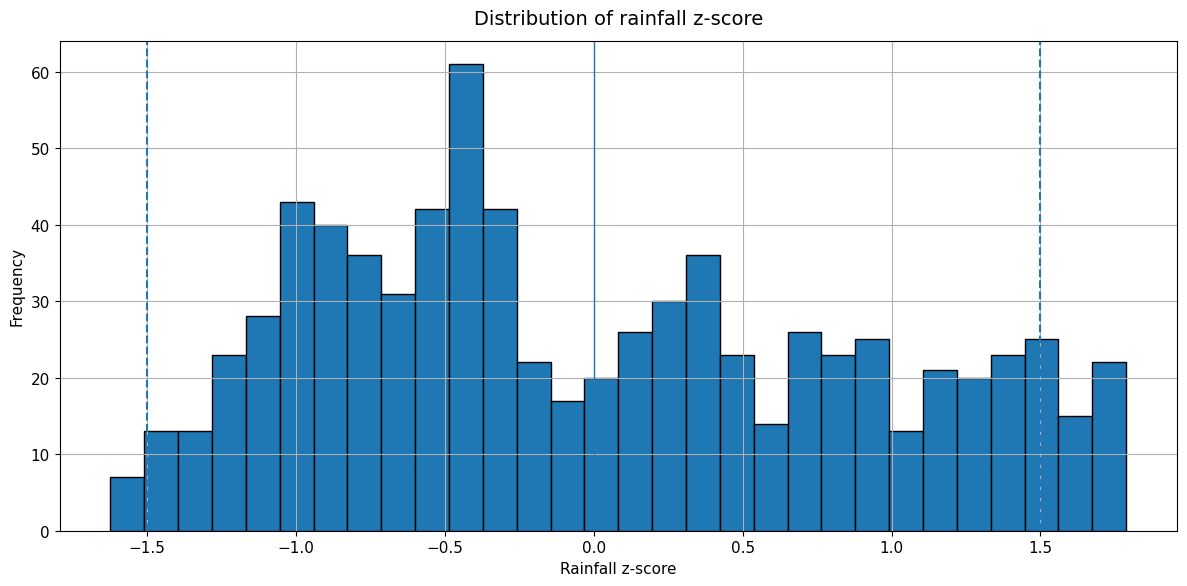

In [25]:
# =========================
# 22. Z-score analysis and extreme months
# =========================

# Common threshold: |z| >= 1.5 or |z| >= 2.
# This dataset's max absolute z-score may be below 2, so use both flexible and strict checks.

df["z_extreme_1_5"] = df["rainfall_zscore"].abs() >= 1.5
df["z_extreme_2_0"] = df["rainfall_zscore"].abs() >= 2.0

print("Extreme records using |z| >= 1.5:", df["z_extreme_1_5"].sum())
print("Extreme records using |z| >= 2.0:", df["z_extreme_2_0"].sum())

extreme_z = (
    df.loc[df["z_extreme_1_5"]]
      .sort_values("rainfall_zscore", key=lambda s: s.abs(), ascending=False)
)

display(extreme_z.head(30))

plt.figure(figsize=(12, 6))
plt.hist(df["rainfall_zscore"], bins=30, edgecolor="black")
plt.axvline(-1.5, linestyle="--")
plt.axvline(1.5, linestyle="--")
plt.axvline(0, linewidth=1)
add_labels(
    "Distribution of rainfall z-score",
    "Rainfall z-score",
    "Frequency"
)
plt.show()

In [26]:
# =========================
# 23. IQR outlier detection on rainfall_mm
# =========================

q1 = df["rainfall_mm"].quantile(0.25)
q3 = df["rainfall_mm"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

df["rainfall_iqr_outlier"] = (
    (df["rainfall_mm"] < lower_bound) |
    (df["rainfall_mm"] > upper_bound)
)

print(f"Q1: {q1:.3f}")
print(f"Q3: {q3:.3f}")
print(f"IQR: {iqr:.3f}")
print(f"Lower bound: {lower_bound:.3f}")
print(f"Upper bound: {upper_bound:.3f}")
print("IQR outlier count:", df["rainfall_iqr_outlier"].sum())

iqr_outliers = df.loc[df["rainfall_iqr_outlier"]].sort_values("rainfall_mm", ascending=False)
display(iqr_outliers.head(30))

Q1: 20.123
Q3: 244.859
IQR: 224.736
Lower bound: -316.981
Upper bound: 581.963
IQR outlier count: 0


,province_name,year,month,date,rainfall_mm,monthly_mean,rainfall_anomaly,rainfall_zscore,year_month,quarter,month_name,season,z_extreme_1_5,z_extreme_2_0,rainfall_iqr_outlier


In [27]:
# =========================
# 24. Wettest and driest records
# =========================

wettest_records = df.sort_values("rainfall_mm", ascending=False).head(20)
driest_records = df.sort_values("rainfall_mm", ascending=True).head(20)

print("Wettest province-month records:")
display(wettest_records)

print("Driest province-month records:")
display(driest_records)

Wettest province-month records:


,province_name,year,month,date,rainfall_mm,monthly_mean,rainfall_anomaly,rainfall_zscore,year_month,quarter,month_name,season,z_extreme_1_5,z_extreme_2_0,rainfall_iqr_outlier
732,Ca Mau,2024,9,2024-09-01,559.464,433.793,125.671,1.226,2024-09,3,September,Rainy season,False,False,False
121,Ca Mau,2020,10,2020-10-01,552.139,355.660,196.479,1.622,2020-10,4,October,Rainy season,True,False,False
108,Ca Mau,2020,9,2020-09-01,530.071,433.793,96.278,0.939,2020-09,3,September,Rainy season,False,False,False
107,Bac Lieu,2020,9,2020-09-01,498.984,397.926,101.058,1.210,2020-09,3,September,Rainy season,False,False,False
556,Kien Giang,2023,7,2023-07-01,498.344,402.488,95.856,1.044,2023-07,3,July,Rainy season,False,False,False
552,Hau Giang,2023,7,2023-07-01,497.324,379.314,118.011,1.208,2023-07,3,July,Rainy season,False,False,False
120,Bac Lieu,2020,10,2020-10-01,497.048,337.609,159.439,1.476,2020-10,4,October,Rainy season,False,False,False
731,Bac Lieu,2024,9,2024-09-01,478.092,397.926,80.166,0.960,2024-09,3,September,Rainy season,False,False,False
546,Soc Trang,2023,7,2023-07-01,475.929,358.010,117.919,0.964,2023-07,3,July,Rainy season,False,False,False
706,Ca Mau,2024,7,2024-07-01,474.851,381.516,93.334,0.801,2024-07,3,July,Rainy season,False,False,False


Driest province-month records:


,province_name,year,month,date,rainfall_mm,monthly_mean,rainfall_anomaly,rainfall_zscore,year_month,quarter,month_name,season,z_extreme_1_5,z_extreme_2_0,rainfall_iqr_outlier
639,Vinh Long,2024,2,2024-02-01,0.000,4.196,-4.196,-1.044,2024-02,1,February,Dry season,False,False,False
642,Can Tho city,2024,2,2024-02-01,0.000,5.587,-5.587,-1.099,2024-02,1,February,Dry season,False,False,False
314,Vinh Long,2022,1,2022-01-01,0.003,6.580,-6.577,-0.830,2022-01,1,January,Dry season,False,False,False
641,Ca Mau,2024,2,2024-02-01,0.024,6.863,-6.839,-0.998,2024-02,1,February,Dry season,False,False,False
640,Bac Lieu,2024,2,2024-02-01,0.025,5.962,-5.937,-1.083,2024-02,1,February,Dry season,False,False,False
643,Hau Giang,2024,2,2024-02-01,0.058,6.153,-6.094,-1.146,2024-02,1,February,Dry season,False,False,False
638,Tra Vinh,2024,2,2024-02-01,0.082,2.593,-2.511,-0.884,2024-02,1,February,Dry season,False,False,False
15,Vinh Long,2020,2,2020-02-01,0.154,4.196,-4.042,-1.006,2020-02,1,February,Dry season,False,False,False
324,Tien Giang,2022,1,2022-01-01,0.166,6.411,-6.245,-0.894,2022-01,1,January,Dry season,False,False,False
646,Dong Thap,2024,2,2024-02-01,0.174,6.367,-6.193,-1.049,2024-02,1,February,Dry season,False,False,False


,avg_rainfall,std_rainfall,min_rainfall,max_rainfall,range_rainfall,cv_rainfall
province_name,,,,,,
Tra Vinh,145.139,125.372,0.082,435.932,435.850,0.864
Ben Tre,134.436,114.289,0.265,411.033,410.769,0.850
Soc Trang,167.606,140.757,0.406,475.929,475.523,0.840
Tien Giang,137.613,112.343,0.166,406.270,406.105,0.816
Bac Lieu,184.402,150.349,0.025,498.984,498.959,0.815
Vinh Long,145.067,118.058,0.000,423.634,423.634,0.814
Ca Mau,196.443,159.411,0.024,559.464,559.440,0.811
Hau Giang,171.126,137.076,0.058,497.324,497.266,0.801
Kien Giang,184.567,144.508,0.274,498.344,498.070,0.783


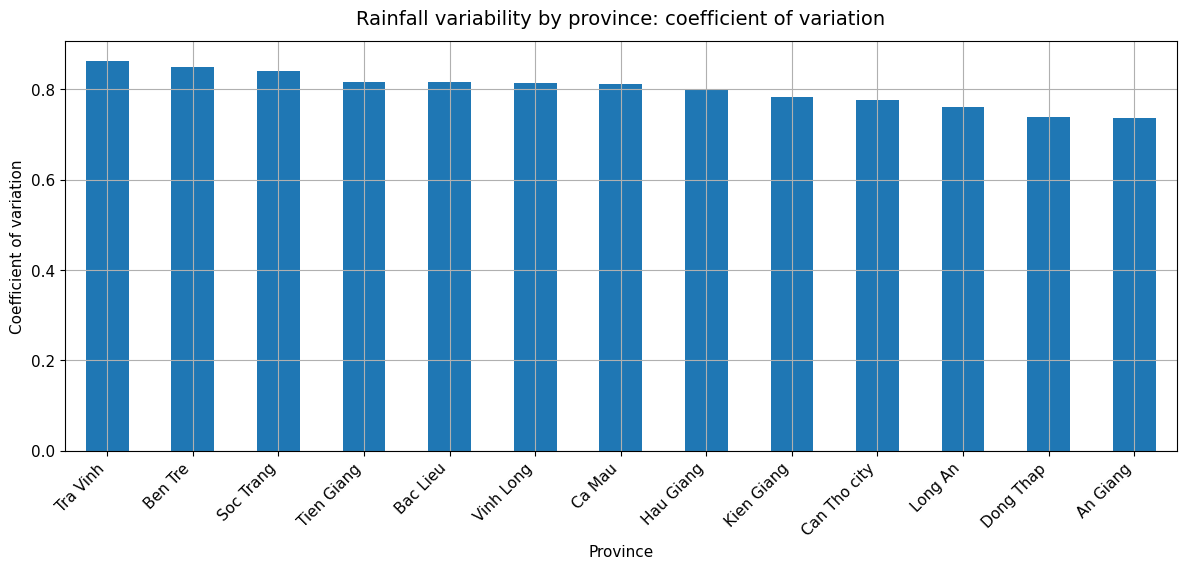

In [28]:
# =========================
# 25. Province-level variability
# =========================

variability = (
    df.groupby("province_name")
      .agg(
          avg_rainfall=("rainfall_mm", "mean"),
          std_rainfall=("rainfall_mm", "std"),
          min_rainfall=("rainfall_mm", "min"),
          max_rainfall=("rainfall_mm", "max"),
      )
)

variability["range_rainfall"] = variability["max_rainfall"] - variability["min_rainfall"]
variability["cv_rainfall"] = variability["std_rainfall"] / variability["avg_rainfall"]
variability = variability.sort_values("cv_rainfall", ascending=False)

display(variability)

plot_bar(
    variability["cv_rainfall"],
    "Rainfall variability by province: coefficient of variation",
    "Province",
    "Coefficient of variation",
    rotation=45
)

,rainfall_mm,monthly_mean,rainfall_anomaly,rainfall_zscore
rainfall_mm,1.000,0.931,0.364,0.304
monthly_mean,0.931,1.000,0.000,-0.000
rainfall_anomaly,0.364,0.000,1.000,0.835
rainfall_zscore,0.304,-0.000,0.835,1.000


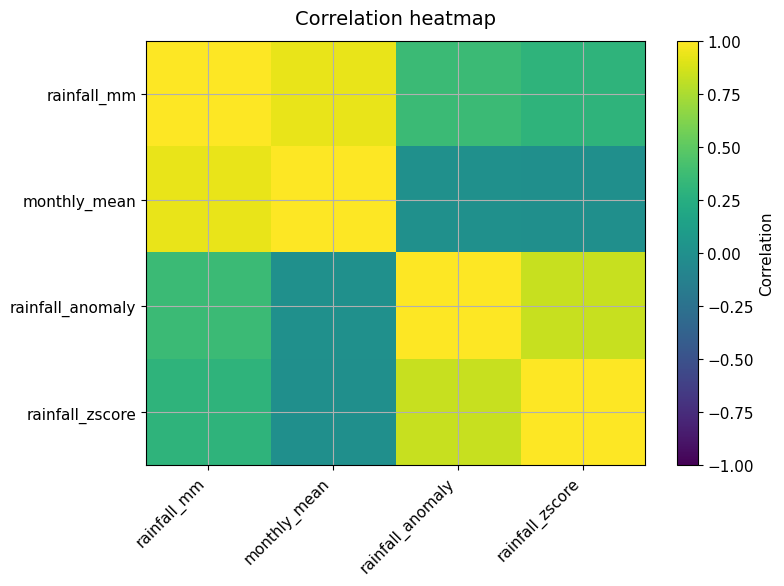

In [29]:
# =========================
# 26. Correlation analysis
# =========================

corr_cols = ["rainfall_mm", "monthly_mean", "rainfall_anomaly", "rainfall_zscore"]
corr = df[corr_cols].corr()

display(corr)

plt.figure(figsize=(8, 6))
plt.imshow(corr.values, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
add_labels(
    "Correlation heatmap",
    "",
    ""
)
plt.show()

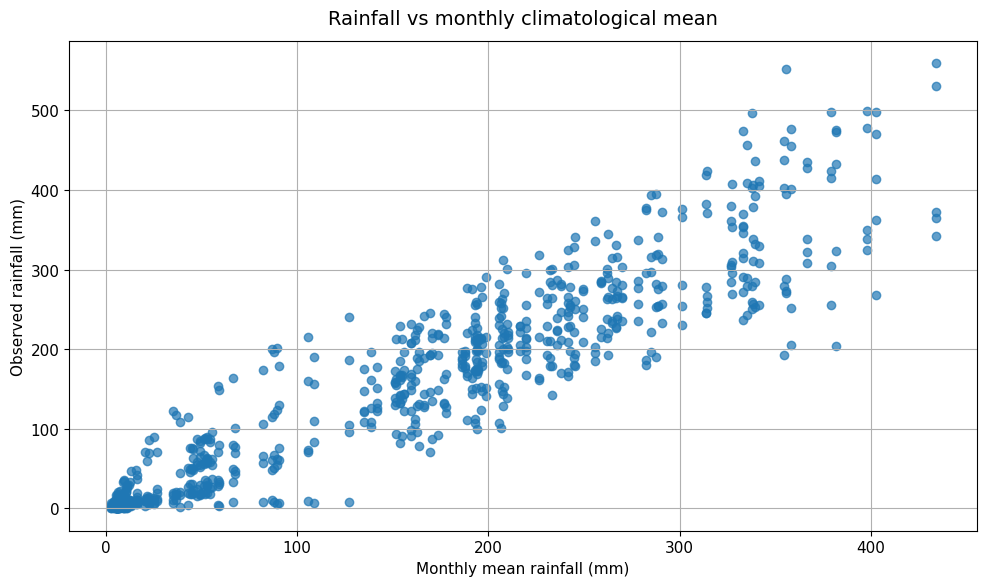

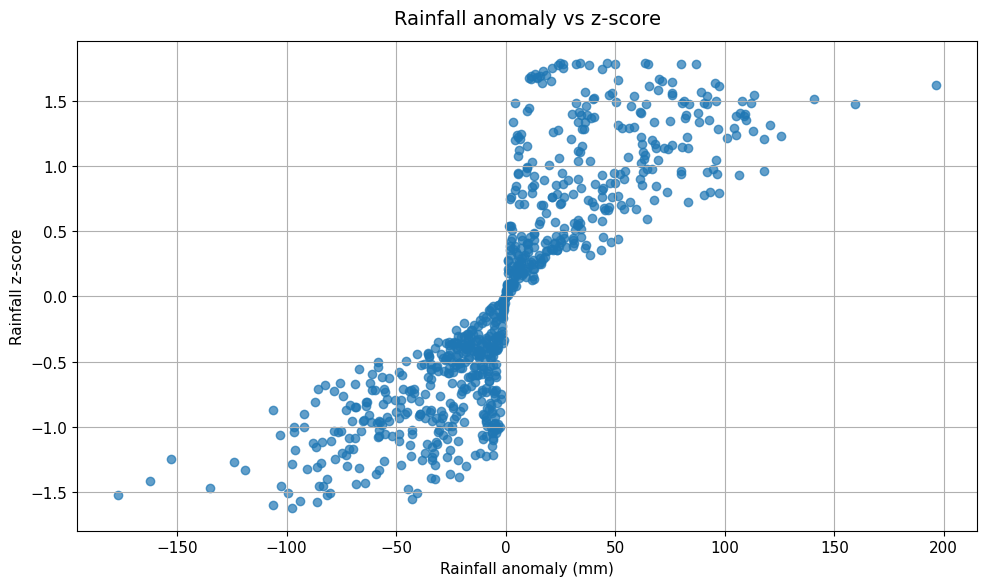

In [30]:
# =========================
# 27. Scatter checks
# =========================

plt.figure(figsize=(10, 6))
plt.scatter(df["monthly_mean"], df["rainfall_mm"], alpha=0.7)
add_labels(
    "Rainfall vs monthly climatological mean",
    "Monthly mean rainfall (mm)",
    "Observed rainfall (mm)"
)
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(df["rainfall_anomaly"], df["rainfall_zscore"], alpha=0.7)
add_labels(
    "Rainfall anomaly vs z-score",
    "Rainfall anomaly (mm)",
    "Rainfall z-score"
)
plt.show()

In [31]:
# =========================
# 28. Identify strongest province-month seasonality patterns
# =========================

# For each province, find the wettest average month and driest average month
province_month_avg = (
    df.groupby(["province_name", "month"], as_index=False)
      .agg(avg_rainfall=("rainfall_mm", "mean"))
)

wettest_month_by_province = (
    province_month_avg.loc[
        province_month_avg.groupby("province_name")["avg_rainfall"].idxmax()
    ]
    .rename(columns={"month": "wettest_month", "avg_rainfall": "wettest_month_avg_rainfall"})
    .set_index("province_name")
)

driest_month_by_province = (
    province_month_avg.loc[
        province_month_avg.groupby("province_name")["avg_rainfall"].idxmin()
    ]
    .rename(columns={"month": "driest_month", "avg_rainfall": "driest_month_avg_rainfall"})
    .set_index("province_name")
)

seasonality_summary = wettest_month_by_province.join(driest_month_by_province)
seasonality_summary["wet_dry_gap"] = (
    seasonality_summary["wettest_month_avg_rainfall"] -
    seasonality_summary["driest_month_avg_rainfall"]
)

seasonality_summary = seasonality_summary.sort_values("wet_dry_gap", ascending=False)

display(seasonality_summary)

,wettest_month,wettest_month_avg_rainfall,driest_month,driest_month_avg_rainfall,wet_dry_gap
province_name,,,,,
Ca Mau,9,433.793,2,6.863,426.930
Bac Lieu,9,397.926,2,5.962,391.964
Kien Giang,7,402.488,2,10.843,391.645
Hau Giang,7,379.314,2,6.153,373.161
Soc Trang,7,358.010,2,5.973,352.037
Ben Tre,10,341.698,2,3.883,337.815
Tra Vinh,10,339.114,2,2.593,336.520
Tien Giang,10,338.230,2,5.119,333.111
Long An,10,333.066,2,5.883,327.183


In [32]:
# =========================
# 29. Compare years within each province
# =========================

province_year_total = (
    df.groupby(["province_name", "year"], as_index=False)
      .agg(
          total_rainfall=("rainfall_mm", "sum"),
          avg_rainfall=("rainfall_mm", "mean"),
          avg_anomaly=("rainfall_anomaly", "mean"),
      )
)

# Best/worst year by total rainfall for each province
wettest_year_by_province = province_year_total.loc[
    province_year_total.groupby("province_name")["total_rainfall"].idxmax()
].sort_values("province_name")

driest_year_by_province = province_year_total.loc[
    province_year_total.groupby("province_name")["total_rainfall"].idxmin()
].sort_values("province_name")

print("Wettest year by province:")
display(wettest_year_by_province)

print("Driest year by province:")
display(driest_year_by_province)

Wettest year by province:


,province_name,year,total_rainfall,avg_rainfall,avg_anomaly
2,An Giang,2022,"1,731.836",144.320,11.431
9,Bac Lieu,2024,"2,441.620",203.468,19.067
14,Ben Tre,2024,"1,797.811",149.818,15.382
19,Ca Mau,2024,"2,636.767",219.731,23.287
22,Can Tho city,2022,"1,822.550",151.879,6.143
27,Dong Thap,2022,"1,681.077",140.090,12.791
32,Hau Giang,2022,"2,169.221",180.768,9.642
36,Kien Giang,2021,"2,321.946",193.495,8.929
42,Long An,2022,"1,943.073",161.923,13.031
49,Soc Trang,2024,"2,215.463",184.622,17.016


Driest year by province:


,province_name,year,total_rainfall,avg_rainfall,avg_anomaly
3,An Giang,2023,"1,483.103",123.592,-9.296
8,Bac Lieu,2023,"2,057.740",171.478,-12.923
13,Ben Tre,2023,"1,459.483",121.624,-12.812
18,Ca Mau,2023,"2,193.659",182.805,-13.638
23,Can Tho city,2023,"1,650.284",137.524,-8.213
28,Dong Thap,2023,"1,417.942",118.162,-9.137
33,Hau Giang,2023,"1,937.837",161.486,-9.640
38,Kien Giang,2023,"2,036.305",169.692,-14.875
40,Long An,2020,"1,662.301",138.525,-10.367
48,Soc Trang,2023,"1,896.929",158.077,-9.529


In [33]:
# =========================
# 30. Simple insight tables for reporting
# =========================

eda_insights = {
    "dataset_shape": df.shape,
    "n_provinces": df["province_name"].nunique(),
    "date_min": str(df["date"].min().date()),
    "date_max": str(df["date"].max().date()),
    "avg_rainfall_mm": df["rainfall_mm"].mean(),
    "median_rainfall_mm": df["rainfall_mm"].median(),
    "max_rainfall_mm": df["rainfall_mm"].max(),
    "min_rainfall_mm": df["rainfall_mm"].min(),
    "wettest_record_province": df.loc[df["rainfall_mm"].idxmax(), "province_name"],
    "wettest_record_date": str(df.loc[df["rainfall_mm"].idxmax(), "date"].date()),
    "driest_record_province": df.loc[df["rainfall_mm"].idxmin(), "province_name"],
    "driest_record_date": str(df.loc[df["rainfall_mm"].idxmin(), "date"].date()),
    "highest_avg_rainfall_province": province_stats.index[0],
    "lowest_avg_rainfall_province": province_stats.index[-1],
    "highest_variability_province": variability.index[0],
}

insight_df = pd.DataFrame(
    [{"metric": k, "value": v} for k, v in eda_insights.items()]
)

display(insight_df)

,metric,value
0,dataset_shape,"(780, 15)"
1,n_provinces,13
2,date_min,2020-01-01
3,date_max,2024-12-01
4,avg_rainfall_mm,155.478
5,median_rainfall_mm,160.929
6,max_rainfall_mm,559.464
7,min_rainfall_mm,0.000
8,wettest_record_province,Ca Mau
9,wettest_record_date,2024-09-01


In [34]:
# =========================
# 31. Export EDA summary tables
# =========================

OUTPUT_DIR = Path("eda_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

province_stats.to_csv(OUTPUT_DIR / "province_stats.csv")
monthly_stats.to_csv(OUTPUT_DIR / "monthly_stats.csv", index=False)
yearly_stats.to_csv(OUTPUT_DIR / "yearly_stats.csv", index=False)
season_stats.to_csv(OUTPUT_DIR / "season_stats.csv")
variability.to_csv(OUTPUT_DIR / "province_variability.csv")
seasonality_summary.to_csv(OUTPUT_DIR / "province_seasonality_summary.csv")
wettest_records.to_csv(OUTPUT_DIR / "wettest_records.csv", index=False)
driest_records.to_csv(OUTPUT_DIR / "driest_records.csv", index=False)
insight_df.to_csv(OUTPUT_DIR / "eda_key_insights.csv", index=False)

print(f"Saved EDA outputs to: {OUTPUT_DIR.resolve()}")
print("Files:")
for f in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", f.name)

Saved EDA outputs to: C:\Users\jimmy\Documents\Tài liệu\vital docs\Side Project\COMP4010-Project-2\data\processed\eda_outputs
Files:
- driest_records.csv
- eda_key_insights.csv
- monthly_stats.csv
- province_seasonality_summary.csv
- province_stats.csv
- province_variability.csv
- season_stats.csv
- wettest_records.csv
- yearly_stats.csv


## Suggested next steps

Sau khi chạy notebook này, bạn có thể tiếp tục theo 3 hướng:

1. **Visualization storytelling**
   - So sánh mùa mưa / mùa khô.
   - Tìm tỉnh có lượng mưa trung bình cao nhất, thấp nhất.
   - Tìm tháng/năm bất thường nhất dựa trên anomaly và z-score.

2. **Feature engineering cho Machine Learning**
   - Lag features: rainfall tháng trước, 3 tháng trước, 12 tháng trước.
   - Rolling mean: trung bình 3 tháng, 6 tháng.
   - Seasonal indicators: rainy/dry season, quarter, month cyclical encoding.

3. **Forecasting / prediction**
   - Predict `rainfall_mm` theo province + year + month.
   - Classify extreme rainfall dựa trên `rainfall_zscore`.
   - Detect anomaly bằng threshold hoặc unsupervised models.